In [20]:
# import numpy as np

# for i in range(3):
#     print(i+1)

# qubit_keys = [f"q{i+1}" for i in range(3)]

# for i in qubit_keys:
#     print(i)

# for i, key in enumerate(range(3)):
#     print(i)

# for i in np.logspace(-2, 0, 50, endpoint=True):
#     print(i)

import json

with open('data/2026-05-05/#367_time_rabi_190700/data.json') as f:
    d = json.load(f)
    print(d.keys())
    print(d['I_data'])

dict_keys(['qubit_key', 'n_avg', 'durations', 'config', 'I_data', 'Q_data', 'fig_live'])
./arrays.npz#I_data


In [ ]:
import numpy as np

data = np.load("data/2026-05-05/#367_time_rabi_190700/arrays.npz")
print(data['durations'])

[  5   7   9  11  13  15  17  19  21  23  25  27  29  31  33  35  37  39
  41  43  45  47  49  51  53  55  57  59  61  63  65  67  69  71  73  75
  77  79  81  83  85  87  89  91  93  95  97  99 101 103 105 107 109 111
 113 115 117 119 121 123 125 127 129 131 133 135 137 139 141 143 145 147
 149 151 153 155 157 159 161 163 165 167 169 171 173 175 177 179 181 183
 185 187 189 191 193 195 197 199 201 203 205 207 209 211 213 215 217 219
 221 223 225 227 229 231 233 235 237 239 241 243 245 247 249 251 253 255
 257 259 261 263 265 267 269 271 273 275 277 279 281 283 285 287 289 291
 293 295 297 299 301 303 305 307 309 311 313 315 317 319 321 323 325 327
 329 331 333 335 337 339 341 343 345 347 349 351 353 355 357 359 361 363
 365 367 369 371 373 375 377 379 381 383 385 387 389 391 393 395 397 399
 401 403 405 407 409 411 413 415 417 419 421 423 425 427 429 431 433 435
 437 439 441 443 445 447 449 451 453 455 457 459 461 463 465 467 469 471
 473 475 477 479 481 483 485 487 489 491 493 495 49

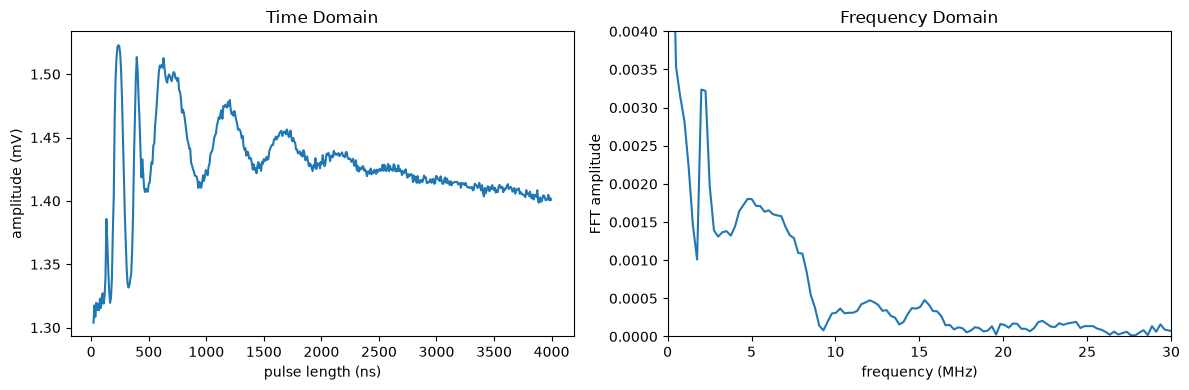

In [40]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("data/2026-05-05/#367_time_rabi_190700/arrays.npz")

pl = data['durations'] * 4e-9   # seconds
I = data['I_data']
Q = data['Q_data']

Amp = np.sqrt(I*I + Q*Q)

# ---- FFT ----
dt = pl[1] - pl[0]              # sampling interval (assumes uniform spacing)
N = len(Amp)

freq = np.fft.fftfreq(N, dt)
Amp_fft = np.fft.fft(Amp)

# Optional: shift zero freq to center
freq_shift = np.fft.fftshift(freq)
Amp_fft_shift = np.fft.fftshift(Amp_fft)

# ---- Plot ----
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Time domain
ax[0].plot(pl / 1e-9, Amp / 1e-3)
ax[0].set_xlabel('pulse length (ns)')
ax[0].set_ylabel('amplitude (mV)')
ax[0].set_title('Time Domain')

# Frequency domain
ax[1].plot(freq_shift / 1e6, np.abs(Amp_fft_shift))
ax[1].set_xlabel('frequency (MHz)')
ax[1].set_ylabel('FFT amplitude')
ax[1].set_title('Frequency Domain')
ax[1].set_yscale('linear')
ax[1].set_xlim([0,30])
ax[1].set_ylim([0,0.004])

plt.tight_layout()
plt.show()

In [44]:
taus = np.logspace(np.log10(16 // 4), np.log10(16_000 // 4), 120)  # Log sweep
print(len(taus))
taus = np.round(taus)
taus = np.unique(taus)
print(len(taus))

120
108


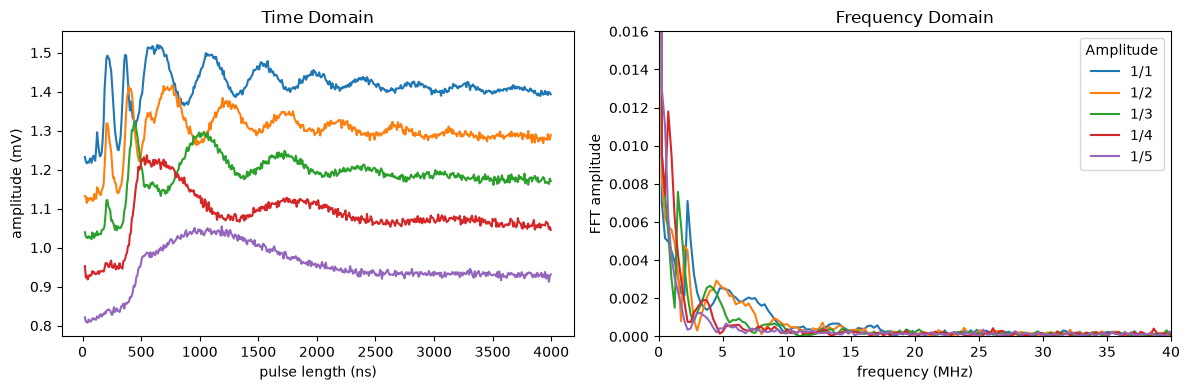

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Plot ----
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

file_list = np.array([
    'data/2026-05-05/#381_time_rabi_195529/arrays.npz',
    'data/2026-05-05/#382_time_rabi_195634/arrays.npz',
    'data/2026-05-05/#383_time_rabi_195745/arrays.npz',
    'data/2026-05-05/#384_time_rabi_200344/arrays.npz',
    'data/2026-05-05/#386_time_rabi_200740/arrays.npz',]
)

for i, file in enumerate(file_list):
    data = np.load(file)

    pl = data['durations'] * 4e-9   # seconds
    I = data['I_data']
    Q = data['Q_data']

    Amp = np.sqrt(I*I + Q*Q)

    # ---- FFT ----
    dt = pl[1] - pl[0]              # sampling interval (assumes uniform spacing)
    N = len(Amp)

    freq = np.fft.fftfreq(N, dt)
    Amp_fft = np.fft.fft(Amp)

    # Optional: shift zero freq to center
    freq_shift = np.fft.fftshift(freq)
    Amp_fft_shift = np.fft.fftshift(Amp_fft)

    # Time domain
    ax[0].plot(pl / 1e-9, Amp / 1e-3 - 0.1*i)

    # Frequency domain
    ax[1].plot(freq_shift / 1e6, np.abs(Amp_fft_shift), label=f'1/{i+1}')

# Time domain
ax[0].set_xlabel('pulse length (ns)')
ax[0].set_ylabel('amplitude (mV)')
ax[0].set_title('Time Domain')


# Frequency domain
ax[1].set_xlabel('frequency (MHz)')
ax[1].set_ylabel('FFT amplitude')
ax[1].set_title('Frequency Domain')
ax[1].set_yscale('linear')
ax[1].set_xlim([0,40])
ax[1].set_ylim([0,0.016])
ax[1].legend(title = 'Amplitude', loc = 'upper right')

plt.tight_layout()
plt.show()